## Classification Using Logistic regrresion
- predict if customer will leave the Bank
- Exited will be a dependent variable 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('Churn_Modelling.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
# Get statistical info
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Data Cleansing

In [5]:
# Since RowNumber CustomerId Surname not useful so we drop them
df.drop(['RowNumber','CustomerId','Surname'],inplace=True,axis=1)

In [6]:
#convert Geography to numrical
from sklearn.preprocessing import LabelEncoder
Encoder = LabelEncoder()
Encoder.fit(df['Geography'])
df['Geography'] = Encoder.transform(df['Geography'])
#convert Gender to numrical
from sklearn.preprocessing import LabelEncoder
Encoder = LabelEncoder()
Encoder.fit(df['Gender'])
df['Gender'] = Encoder.transform(df['Gender'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


In [8]:
#Check if any Missing values
df.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
##corr -> corelation coeffient :[-1 to 1]
# if -1 : Perfect negative corelation
# if  1 : perfect +ve corelation
# 0 : no relation (less important)
df.corr()['Exited'].abs().sort_values()

HasCrCard          0.007138
EstimatedSalary    0.012097
Tenure             0.014001
CreditScore        0.027094
Geography          0.035943
NumOfProducts      0.047820
Gender             0.106512
Balance            0.118533
IsActiveMember     0.156128
Age                0.285323
Exited             1.000000
Name: Exited, dtype: float64

In [10]:
#check the dataset is balanced or not 
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

### Data Preprossecing

In [11]:
# Split the data into x and y
x = df.drop('Exited',axis=1)
y = df['Exited']


In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

### Train the Model

In [13]:
from sklearn.linear_model import LogisticRegressionCV
model = LogisticRegressionCV(max_iter=1000)
model.fit(x_train,y_train)

C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplifie

,"max_iter max_iter: int, default=100Maximum number of iterations of the optimization algorithm.",1000
,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add an L2 penalty term (used by default);- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy <accuracy_score>` is used... versionchanged:: 1.11 The default will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11.",'warn'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'lib

 ### Model Evaluation

In [14]:
#predict the x_test dataset
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

### Confusion metrics

In [15]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[1562,   45],
       [ 321,   72]])

In [16]:
# Find the Positions 
tn,fp,fn,tp = cm.ravel()
print(f"tn:{tn}, fp:{fp}, fn:{fn}, tp:{tp}")

tn:1562, fp:45, fn:321, tp:72


In [17]:
# Accuracy 
from sklearn.metrics import accuracy_score
accuracy = (tp+tn)/(tn+fp+fn+tp)
print(f"Accuracy : {accuracy *100:.2f}")
a = accuracy_score(y_test,y_pred)
print(f"Accuracy : {a*100:.2f}")

Accuracy : 81.70
Accuracy : 81.70


In [21]:
#Precision
from sklearn.metrics import precision_score
precision = precision_score(y_test,y_pred)
print(f"Precision : {precision:.2f}")
pr = tp/(tp+fp)
print(f"Precision : {precision:.2f}")

Precision : 0.62
Precision : 0.62


In [25]:
#Recall
from sklearn.metrics import recall_score
recall = recall_score(y_test,y_pred)
print(f"recall : {recall:.2f}%")
r = tp/(tp+fn)
print(f"recall : {r:.2f}%")

recall : 0.18%
recall : 0.18%


In [28]:
#F1 Score
from sklearn.metrics import f1_score
f1_score = f1_score(y_test,y_pred)
print(f"F1 Score = {f1_score:.2f}")
f1 = 2*(precision*recall)/(precision+recall)
print(f"F1 : {f1_score:.2f}")

F1 Score = 0.28
F1 : 0.28


In [34]:
#roc value
from sklearn.metrics import roc_auc_score
roc = roc_auc_score(y_test,y_pred)
print(f"ROC-AUC = {roc:.2f}")

ROC-AUC = 0.58


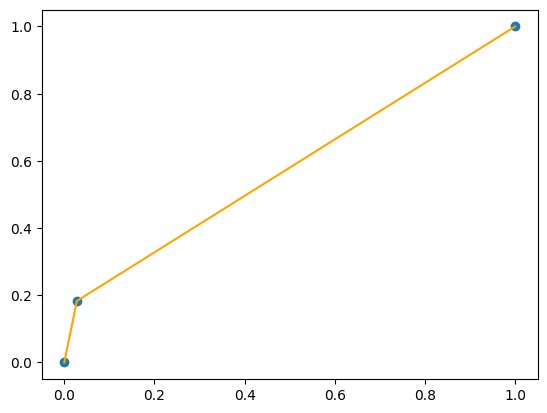

In [43]:
#Roc curve
from sklearn.metrics import roc_curve
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
plt.scatter(fpr,tpr)
plt.plot(fpr,tpr,color='orange')

### result Visualization

Text(0.5, 1.0, 'Classification label')

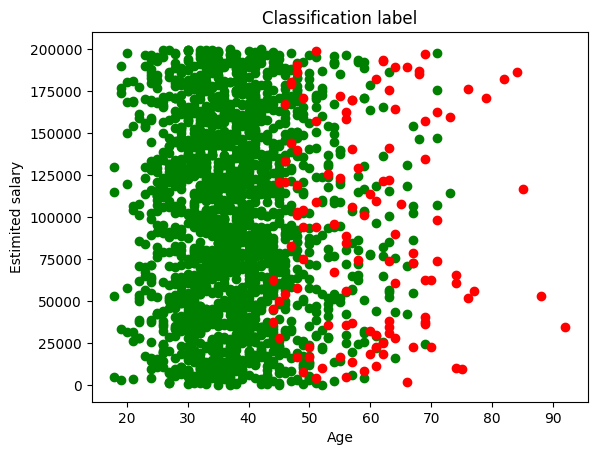

In [40]:
plt.scatter(x_test['Age'][y_pred==0],x_test['EstimatedSalary'][y_pred==0],color='green')
plt.scatter(x_test['Age'][y_pred==1],x_test['EstimatedSalary'][y_pred==1],color='red')
plt.xlabel('Age')
plt.ylabel('Estimited salary')
plt.title('Classification label')